1. Импортируем библиотеки, загружаем данные

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df = pd.read_csv('hh_database.csv', sep=';', encoding='utf-8')
df.head()

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
0,"Мужчина , 39 лет , родился 27 ноября 1979",29000 руб.,Системный администратор,"Советск (Калининградская область) , не готов к...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...",Опыт работы 16 лет 10 месяцев Август 2010 — п...,"МАОУ ""СОШ № 1 г.Немана""",Системный администратор,Неоконченное высшее образование 2000 Балтийск...,16.04.2019 15:59,Имеется собственный автомобиль
1,"Мужчина , 60 лет , родился 20 марта 1959",40000 руб.,Технический писатель,"Королев , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, уд...",Опыт работы 19 лет 5 месяцев Январь 2000 — по...,Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",Высшее образование 1981 Военно-космическая ак...,12.04.2019 08:42,Не указано
2,"Женщина , 36 лет , родилась 12 августа 1982",20000 руб.,Оператор,"Тверь , не готова к переезду , не готова к ком...",полная занятость,полный день,Опыт работы 10 лет 3 месяца Октябрь 2004 — Де...,ПАО Сбербанк,Кассир-операционист,Среднее специальное образование 2002 Профессио...,16.04.2019 08:35,Не указано
3,"Мужчина , 38 лет , родился 25 июня 1980",100000 руб.,Веб-разработчик (HTML / CSS / JS / PHP / базы ...,"Саратов , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, удаленная работа",Опыт работы 18 лет 9 месяцев Август 2017 — Ап...,OpenSoft,Инженер-программист,Высшее образование 2002 Саратовский государст...,08.04.2019 14:23,Не указано
4,"Женщина , 26 лет , родилась 3 марта 1993",140000 руб.,Региональный менеджер по продажам,"Москва , не готова к переезду , готова к коман...",полная занятость,полный день,Опыт работы 5 лет 7 месяцев Региональный мене...,Мармелад,Менеджер по продажам,Высшее образование 2015 Кгу Психологии и педаг...,22.04.2019 10:32,Не указано


2. Изучим данные

In [48]:
df.shape

(44744, 12)

In [49]:
df.describe()

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
count,44744,44744,44744,44744,44744,44744,44576,44743,44742,44744,44744,44744
unique,16003,690,14929,10063,38,47,44413,30214,16927,40148,18838,2
top,"Мужчина , 32 года , родился 17 сентября 1986",50000 руб.,Системный администратор,"Москва , не готов к переезду , не готов к кома...",полная занятость,полный день,Опыт работы 10 лет 8 месяцев Апрель 2018 — по...,Индивидуальное предпринимательство / частная п...,Системный администратор,Высшее образование 2014 Тюменский Государствен...,07.05.2019 09:50,Не указано
freq,18,4064,3099,1261,30026,22727,3,935,2062,4,25,32268


In [50]:
# смотрим типы данных и наличие пустых значений

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Пол, возраст                     44744 non-null  object
 1   ЗП                               44744 non-null  object
 2   Ищет работу на должность:        44744 non-null  object
 3   Город, переезд, командировки     44744 non-null  object
 4   Занятость                        44744 non-null  object
 5   График                           44744 non-null  object
 6   Опыт работы                      44576 non-null  object
 7   Последнее/нынешнее место работы  44743 non-null  object
 8   Последняя/нынешняя должность     44742 non-null  object
 9   Образование и ВУЗ                44744 non-null  object
 10  Обновление резюме                44744 non-null  object
 11  Авто                             44744 non-null  object
dtypes: object(12)
memory usage: 4.1+

3. Подготовка данных

In [51]:
# проверяем и удаляем дубли
df[df.duplicated()]

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
380,"Мужчина , 38 лет , родился 15 ноября 1980",55000 руб.,"системный администратор, информационная безопа...","Красноярск , не готов к переезду , готов к ком...","частичная занятость, полная занятость","гибкий график, полный день, удаленная работа",Опыт работы 17 лет 3 месяца Декабрь 2017 — по...,"ООО ""Техкомплект""",Системный администратор,Высшее образование 1999 Красноярский государс...,10.04.2019 15:37,Имеется собственный автомобиль
543,"Мужчина , 26 лет , родился 22 августа 1992",37000 руб.,Аналитик,"Санкт-Петербург , не готов к переезду , готов ...",полная занятость,полный день,Опыт работы 3 года 4 месяца Январь 2018 — по ...,Федеральная служба по регулированию алкогольно...,Главный специалист-эксрепт,Высшее образование 2014 Санкт-Петербургский у...,16.04.2019 19:08,Не указано
876,"Мужчина , 36 лет , родился 13 февраля 1983",35000 руб.,Системный администратор,"Челябинск , не готов к переезду , готов к редк...",полная занятость,полный день,Опыт работы 8 лет 3 месяца Сентябрь 2007 — Ма...,ЗАО БАНК РУССКИЙ СТАНДАРТ,Специалист отдела информационных технологий,Высшее образование 2006 Челябинский государст...,20.04.2019 09:10,Имеется собственный автомобиль
1038,"Мужчина , 29 лет , родился 12 октября 1989",180000 руб.,Главный инженер проекта,"Москва , м. Бабушкинская , готов к переезду ,...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...",Опыт работы 10 лет 5 месяцев Май 2016 — по на...,"ООО ""Локальные сети""",Главный инженер,Высшее образование 2015 Московский государств...,16.04.2019 23:32,Не указано
1116,"Мужчина , 37 лет , родился 2 июля 1981",90000 руб.,Руководитель отдела программирования станков с...,"Уфа , готов к переезду , готов к командировкам","проектная работа, полная занятость","полный день, сменный график",Опыт работы 14 лет Апрель 2017 — по настоящее...,Инженерный Центр Металлообработки,Технический директор,"Высшее образование 2005 ГОУ ВПО ""Уфимский госу...",21.04.2019 00:11,Имеется собственный автомобиль
...,...,...,...,...,...,...,...,...,...,...,...,...
6506,"Мужчина , 38 лет , родился 3 марта 1981",30000 руб.,Сервисный инженер,"Калининград , готов к переезду , готов к редки...","частичная занятость, полная занятость","гибкий график, полный день, сменный график, ва...",Опыт работы 11 лет 7 месяцев Январь 2016 — Ян...,ООО Саммит моторс,мастер участка подготовки,Неоконченное высшее образование 2006 Томский ...,14.04.2019 23:32,Не указано
6511,"Мужчина , 31 год , родился 25 мая 1987",51500 руб.,"Системный администратор, Сервисный инженер, по...","Москва , м. Щелковская , готов к переезду , г...",полная занятость,"гибкий график, полный день, сменный график",Опыт работы 11 лет 9 месяцев Сентябрь 2018 — ...,Ponominalu.ru,Старший специалист технической поддержки,Высшее образование 2011 Московский Государстве...,15.04.2019 04:17,Не указано
6535,"Мужчина , 39 лет , родился 31 января 1980",1290 USD,"Интернет-маркетолог, руководитель (Продажи чер...","Нижний Новгород , готов к переезду , готов к к...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график",Опыт работы 19 лет 2 месяца Март 2018 — Май ...,Русдекинг,Руководитель отдела маркетинга,Высшее образование 2006 Нижегородский государ...,10.04.2019 12:34,Имеется собственный автомобиль
6541,"Мужчина , 37 лет , родился 15 мая 1981",40000 руб.,Монтажник слаботочных систем,"Зеленоград , не готов к переезду , готов к ред...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график",Опыт работы 9 лет 9 месяцев Декабрь 2017 — Ок...,Пожарная безопасность ат,Инженер пожарной безопасности,Среднее специальное образование 1999 впту-313 ...,15.04.2019 19:34,Не указано


In [52]:
df.drop_duplicates(inplace=True)

3.1. Пол, возраст.
Нулевые значения отсутствуют, необходимо разделить значения в столбце и убрать лишнюю информацию(дата рождения)

In [53]:
df['Пол'] = df['Пол, возраст'].str.split(',').str[0].str.rstrip()
df['Пол'].unique()

array(['Мужчина', 'Женщина'], dtype=object)

In [54]:
df['Возраст'] = df['Пол, возраст'].str.extract(r'(\d+)')[0].astype(int)
df['Возраст'].describe()

count    44591.000000
mean        32.194815
std          7.924196
min         14.000000
25%         27.000000
50%         31.000000
75%         36.000000
max        100.000000
Name: Возраст, dtype: float64

Начальное значение возраста кажется логичным для подработок, но верхняя граница вызывает подозрение, необходимо проверить выбросы.
Логарифмируем данные по возрасту для приближения к нормальному распределению и сделаем послабление на верхнюю границу ввиду нормальности ситуации по поиску работы людей более старшего возраста.

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто,Пол,Возраст
33654,"Мужчина , 100 лет , родился 1 января 1919",60000 руб.,Frontend-разработчик,"Санкт-Петербург , не готов к переезду , готов ...","стажировка, частичная занятость, проектная раб...","гибкий график, полный день, удаленная работа",Опыт работы 2 года 6 месяцев Февраль 2019 — п...,Freelance,Frontend-разработчик,Среднее специальное образование 2015 Санкт-Пе...,19.04.2019 23:27,Не указано,Мужчина,100


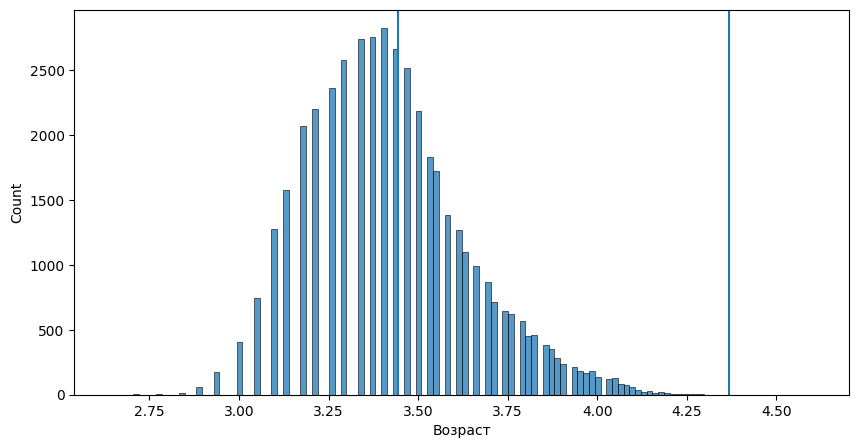

In [55]:
log_age = np.log(df['Возраст'])

mean = log_age.mean()
std = log_age.std()

plt.figure(figsize=(10, 5))
sns.histplot(log_age)

plt.axvline(mean)
plt.axvline(mean + 4*std)

upper_bound = mean + 4 * std
df[log_age > upper_bound]


В данном случае выбросом является знаечние в 100 лет. В целом мы можем просто удалить это значение как нерелевантное и единичное.
При значимых потерях данных можно было учесть дату сбора данных, год получения образования и средний возраст получения образования указанного уровня в РФ.
Так же удалим старый столбец - необходимые данные уже перенесены в новые столбцы.

In [56]:
df = df[log_age < upper_bound].reset_index(drop=True)
df.drop(columns='Пол, возраст', inplace=True)

3.2. ЗП
Необходимо посмотреть в одной ли валюте указаны данные, если нет - перевести в одну валюту, после чего сделать поле числовым.
Проверить значения на наличие выбросов.

In [57]:
salary_split = df['ЗП'].str.split(' ', expand=True)
df['ЗП_сумма'] = salary_split[0].astype(float)
df['ЗП_валюта'] = salary_split[1]

df['ЗП_валюта'].value_counts()

ЗП_валюта
руб.        42319
KZT          1108
USD           626
бел.руб.      329
EUR           106
грн.           73
сум            20
KGS             6
AZN             3
Name: count, dtype: int64

In [58]:
# чтобы пересчитать ЗП в рубли воспользуемся дополнительно табличкой с курсами валют, а так же переведем данные в поле "Обновление резюме" в дату для выбора актуального курса

df = df.copy() # явно используем датафрейм, а не срез

df['Обновление резюме'] = pd.to_datetime(df['Обновление резюме'], dayfirst=True).dt.normalize()

currencies = pd.read_csv('ExchangeRates.csv', sep=',')
currencies['date'] = pd.to_datetime(
    currencies['date'],
    format='%d/%m/%y'
)

df = df.merge(currencies, left_on=['Обновление резюме', 'ЗП_валюта'], right_on=['date', 'currency'], how='left')


In [59]:
df['close'] = df['close'].astype(float)
df.loc[df['ЗП_валюта'] == 'руб.', 'close'] = 1 # выставляем курс для рублей

df['proportion'] = df['proportion'].fillna(1) # заполняем значение для рублей = 1
df["ЗП (руб)"] = df['ЗП_сумма'] * df['close'] / df['proportion']

df = df.drop(columns=['currency', 'per', 'date', 'time', 'close', 'vol', 'proportion', 'ЗП'])

In [60]:
# посмотрим как распределены значения
df['ЗП (руб)'].describe().map('{:.0f}'.format)

count       44168
mean        76889
std        136651
min             1
25%         40000
50%         60000
75%         95000
max      24304876
Name: ЗП (руб), dtype: object

In [61]:
# уберем значения ниже 1_000 рублей и больше 1_000_000 рублей

df = df[df['ЗП (руб)'].between(1_000, 1_000_000)]

3.3. Город, переезд, командировки	
Города разделим на Москву, Санкт-Петербург, Города-миллионники и Другие
Готовность к переезду и командировкам переведем в отдельные булевы столбцы

In [62]:
df['Город'] = df['Город, переезд, командировки'].str.split(' , ').str[0]
df['Город'].value_counts()


Город
Москва             16539
Санкт-Петербург     4913
Краснодар           1057
Новосибирск          956
Казань               862
                   ...  
Вяземский              1
Грайворон              1
Ялуторовск             1
Адыгейск               1
Кременки               1
Name: count, Length: 962, dtype: int64

In [63]:
million_cities = ['Новосибирск', 'Екатеринбург','Нижний Новгород','Казань', 'Челябинск','Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж','Волгоград']
df['Город'] = df['Город'].apply(
    lambda x: 'Москва' if x == 'Москва'
    else 'Санкт-Петербург' if x == 'Санкт-Петербург'
    else 'город-миллионник' if x in million_cities
    else 'другие'
)

df['Готовность к переезду'] = ~df['Город, переезд, командировки'].str.contains('не готов(а)? к переезду')
df['Готовность к командировкам'] = ~df['Город, переезд, командировки'].str.contains('не готов(а)? к командировкам')

df.drop(columns='Город, переезд, командировки', inplace=True)

C:\Temp\ipykernel_17020\3025136656.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['Готовность к переезду'] = ~df['Город, переезд, командировки'].str.contains('не готов(а)? к переезду')
C:\Temp\ipykernel_17020\3025136656.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['Готовность к командировкам'] = ~df['Город, переезд, командировки'].str.contains('не готов(а)? к командировкам')


3.4. Занятость
Посмотрим возможные значения поля и сделаем несколько булевых столбцов

In [64]:
employment = df['Занятость'].str.split(', ').explode().unique()
employment

array(['частичная занятость', 'проектная работа', 'полная занятость',
       'стажировка', 'волонтерство'], dtype=object)

In [65]:
for empl in employment:
    df[empl] = df['Занятость'].str.contains(empl)

3.5. График
Выполним разбивку по аналогии с предыдущим пунктом и удалим более ненужные столбцы

In [66]:
schedule = df['График'].str.split(', ').explode().unique()

for sch in schedule:
    df[sch] = df['График'].str.contains(sch)

df = df.drop(columns=['Занятость', 'График'])


3.6. Опыт работы
Необходимо привести значения к одному удобному формату.
Учитываем что есть пустые значения. В данном случае предположим что они говорят об отсутствии опыта. 

In [67]:
df[~df['Опыт работы'].str.contains('Опыт работы', na=False)].value_counts()
#видим что так же есть значения вида "Не указано"

Ищет работу на должность:                      Опыт работы  Последнее/нынешнее место работы  Последняя/нынешняя должность  Образование и ВУЗ                                                                                                                                                                                                                                                                         Обновление резюме  Авто                            Пол      Возраст  ЗП_сумма  ЗП_валюта  ЗП (руб)  Город             Готовность к переезду  Готовность к командировкам  частичная занятость  проектная работа  полная занятость  стажировка  волонтерство  гибкий график  полный день  сменный график  вахтовый метод  удаленная работа
Системный администратор                        Не указано   Европа, Торговая сеть            Системный администратор       Высшее образование 2015  Белгородский государственный университет, Белгород Компьютерных наук и телекоммуникаций, Фундаментальная информатика и

In [68]:
experience = df['Опыт работы'].replace('Не указано', 0)
years = df['Опыт работы'].str.extract(r'Опыт работы (\d+) (?:год|лет)')[0].astype(float)
months = df['Опыт работы'].str.extract(r'(\d+) (?:мес)')[0].astype(float)
df['Опыт работы (лет)'] = years.fillna(0) + months.fillna(0)/12

df.drop(columns='Опыт работы', inplace=True)

In [69]:
# удалим случаи, где опыт работы превышает возраст

df = df[df['Опыт работы (лет)'] < df['Возраст']]

3.7. Последнее/нынешнее место работы и Последняя/нынешняя должность
Заполним значением 'Не указано' для пустых строк

In [70]:
df['Последнее/нынешнее место работы'] = df['Последнее/нынешнее место работы'].fillna('Не указано')
df['Последняя/нынешняя должность'] = df['Последняя/нынешняя должность'].fillna('Не указано')

3.8. Образование и ВУЗ.
Для нас важен уровень образования, поэтому оставим только эти значения

In [71]:
df['Образование'] = df['Образование и ВУЗ'].str.lower().str.extract(r'^(высшее|неоконченное высшее|среднее специальное|среднее)', expand=False)

df.drop(columns='Образование и ВУЗ', inplace=True)

df['Образование'].unique()

array(['неоконченное высшее', 'высшее', 'среднее специальное', 'среднее'],
      dtype=object)

4. Анализ данных

4.1. Посмотрим распределения основных параметров: возраст, опыт работы, зарплатные ожидания

Text(0.5, 0, 'Возраст')

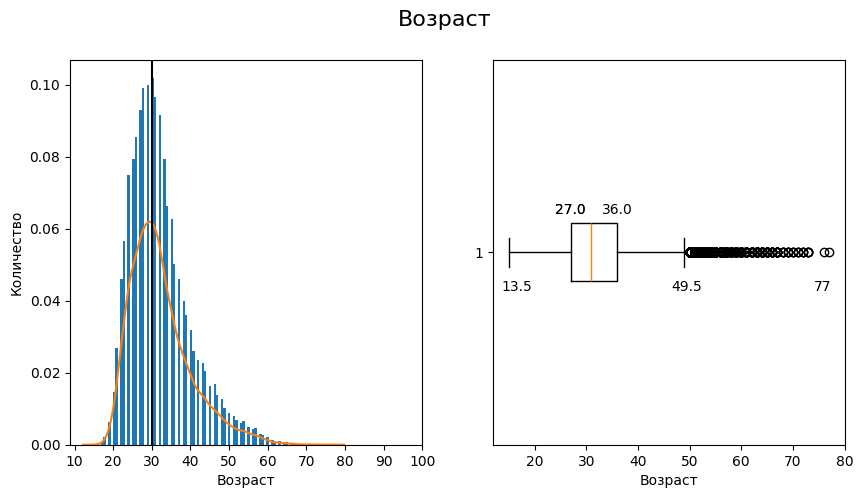

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].hist(df['Возраст'], bins = 100, density=True)
sns.kdeplot(df['Возраст'], ax=axes[0])
axes[1].boxplot(df['Возраст'], vert=False)

q1 = np.percentile(df['Возраст'], 25)
q3 = np.percentile(df['Возраст'], 75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
max_value = df['Возраст'].max()

mode = df['Возраст'].mode()[0]
axes[0].axvline(mode, color='black')

fig.suptitle('Возраст', fontsize=16)

axes[1].text(q1-3, 1.1, f'{q1}')
axes[1].text(q3-3, 1.1, f'{q3}')
axes[1].text(lower, 0.9, f'{lower}')
axes[1].text(upper-3, 0.9, f'{upper}')
axes[1].text(max_value-3, 0.9, f'{max_value}')
axes[1].text(q1-3, 1.1, f'{q1}')

axes[0].set_xticks(range(10, 101, 10))
axes[0].set_xlabel('Возраст')
axes[0].set_ylabel('Количество')
axes[1].set_xlabel('Возраст')


In [73]:
df['Возраст'].describe()

count    44073.000000
mean        32.216459
std          7.922534
min         15.000000
25%         27.000000
50%         31.000000
75%         36.000000
max         77.000000
Name: Возраст, dtype: float64

Text(0.5, 0, 'Опыт работы')

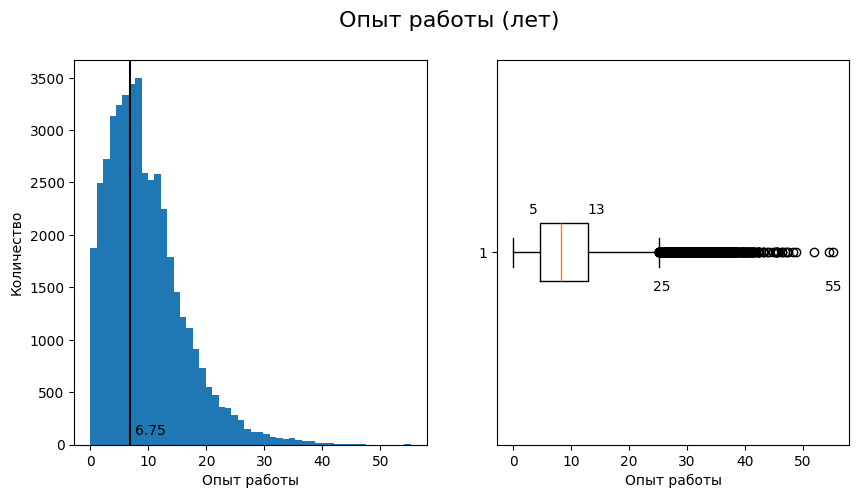

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].hist(df['Опыт работы (лет)'], bins = 50)
axes[1].boxplot(df['Опыт работы (лет)'], vert=False)

mode = df['Опыт работы (лет)'].mode()[0]
max_v = df['Опыт работы (лет)'].max()
min_v = df['Опыт работы (лет)'].min()
q1 = df['Опыт работы (лет)'].quantile(0.25)
q3 = df['Опыт работы (лет)'].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr

fig.suptitle('Опыт работы (лет)', fontsize=16)

axes[0].axvline(mode, color='black')

axes[1].text(q1-2, 1.1, f'{round(q1)}')
axes[1].text(q3, 1.1, f'{round(q3)}')
axes[1].text(upper-1, 0.9, f'{round(upper)}')
axes[1].text(max_v-1.5, 0.9, f'{round(max_v)}')

axes[0].text(mode+1, 100, f'{mode}')
axes[0].set_xlabel('Опыт работы')
axes[0].set_ylabel('Количество')
axes[1].set_xlabel('Опыт работы')


Text(0.5, 0, 'ЗП (тыс. руб)')

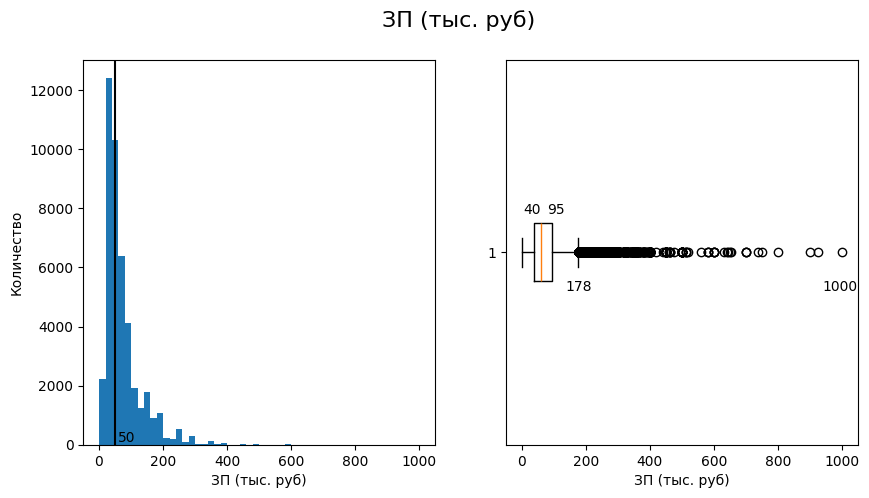

In [75]:
df['ЗП (тыс. руб)'] = df['ЗП (руб)']/1000

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].hist(df['ЗП (тыс. руб)'], bins = 50)
axes[1].boxplot(df['ЗП (тыс. руб)'], vert=False)

mode = df['ЗП (тыс. руб)'].mode()[0]
max_v = df['ЗП (тыс. руб)'].max()
min_v = df['ЗП (тыс. руб)'].min()
q1 = df['ЗП (тыс. руб)'].quantile(0.25)
q3 = df['ЗП (тыс. руб)'].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr

fig.suptitle('ЗП (тыс. руб)', fontsize=16)

axes[0].axvline(mode, color='black')
axes[0].text(mode+10, 100, f'{round(mode)}')
axes[0].set_xlabel('ЗП (тыс. руб)')
axes[0].set_ylabel('Количество')

axes[1].text(q1-35, 1.1, f'{round(q1)}')
axes[1].text(q3-15, 1.1, f'{round(q3)}')
axes[1].text(upper-40, 0.9, f'{round(upper)}')
axes[1].text(max_v-60, 0.9, f'{round(max_v)}')
axes[1].set_xlabel('ЗП (тыс. руб)')


4.2. Рассмотрим зависимость медианной заработной платы от уровня образования

Образование
среднее специальное     NaN
среднее                 0.0
неоконченное высшее    25.0
высшее                 20.0
Name: ЗП (руб), dtype: float64

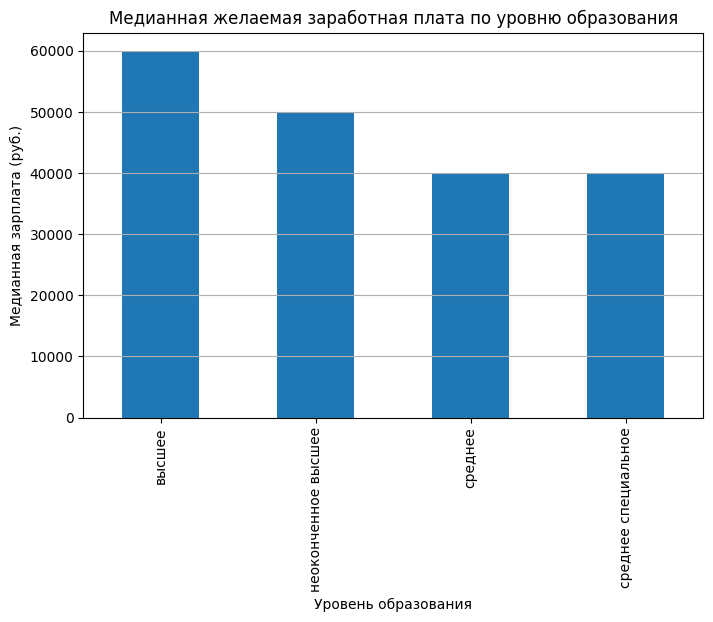

In [76]:
median_salary = df.groupby('Образование')['ЗП (руб)'].median()
median_salary.plot(kind='bar', figsize=(8, 5))

plt.title('Медианная желаемая заработная плата по уровню образования')
plt.xlabel('Уровень образования')
plt.ylabel('Медианная зарплата (руб.)')
plt.grid(axis='y')

median_salary.sort_values().pct_change() * 100

Наблюдается рост ожидаемой заработной платы с ростом уровня образования соискателей. При среднем образовании различия между общим и специальным образованием практически отсутствуют.
В целом разница между уровнями зарплат может составлять более 20%.

4.3. Рассмотрим зависимость уровня ожидаемой заработной платы от города

Город
другие                0.0
город-миллионник      0.0
Санкт-Петербург      50.0
Москва              112.5
Name: ЗП (руб), dtype: float64

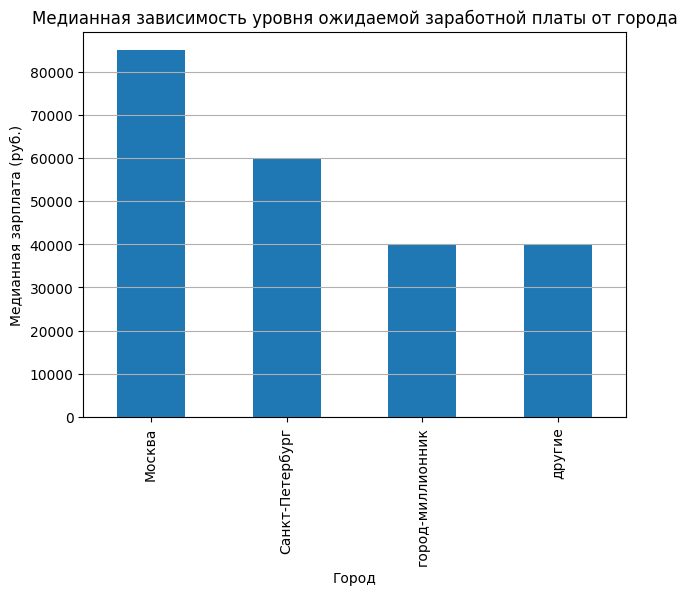

In [77]:
salary_by_city = df.groupby('Город')['ЗП (руб)'].median()
salary_by_city.plot(kind='bar', figsize=(7,5))

plt.title('Медианная зависимость уровня ожидаемой заработной платы от города')
plt.ylabel('Медианная зарплата (руб.)')
plt.grid(axis='y')

order = [
    'другие',
    'город-миллионник',
    'Санкт-Петербург',
    'Москва'
]

salary_by_city = salary_by_city.reindex(order)
(salary_by_city - salary_by_city.iloc[0]) / salary_by_city.iloc[0] * 100

Город заметно влияет на уровень ожидаемой заработной платы. В Санкт-Петербурге зарплатные ожидания примерно на 50% выше, чем в других городах(за исключением столицы), а в Москве они превышают этот уровень более чем в два раза. При этом между остальными городами-миллионниками и городами с меньшей численностью населения существенных различий в зарплатных ожиданиях не наблюдается.

4.4. Рассмотрим зависимость ожидаемой заработной платы от готовности к командировкам и переездам

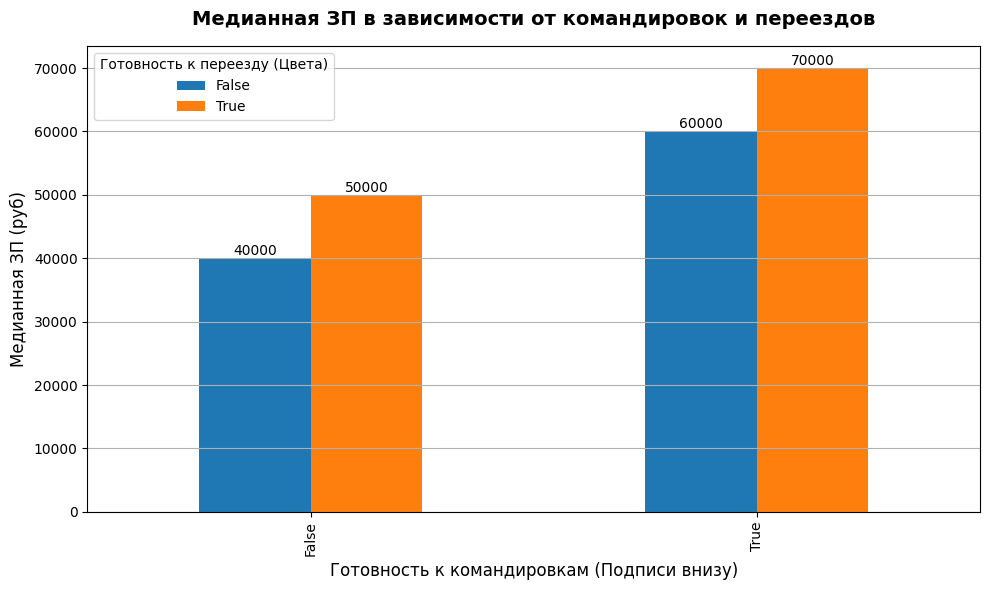

In [78]:
pivot_df = df.pivot_table(
    values='ЗП (руб)', 
    index='Готовность к командировкам', 
    columns='Готовность к переезду', 
    aggfunc='median'
)

ax = pivot_df.plot(kind='bar', figsize=(10, 6))

plt.title('Медианная ЗП в зависимости от командировок и переездов', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Готовность к командировкам (Подписи внизу)', fontsize=12)
plt.ylabel('Медианная ЗП (руб)', fontsize=12)

plt.legend(title='Готовность к переезду (Цвета)')
plt.grid(axis='y') # легкая сетка для удобства

# цифры над столбцами
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

И готовность к переезду, и готовность к командировкам связаны с более высоким уровнем ожидаемой заработной платы. На графике наблюдается последовательный рост зарплатных ожиданий в зависимости от готовности к дополнительной мобильности:
не готов к переезду и командировкам → готов только к переезду → готов только к командировкам → готов и к переезду, и к командировкам.

4.5. Рассмотрим зависимость медианной заработной платы от возраста соискателей и уровня их образования

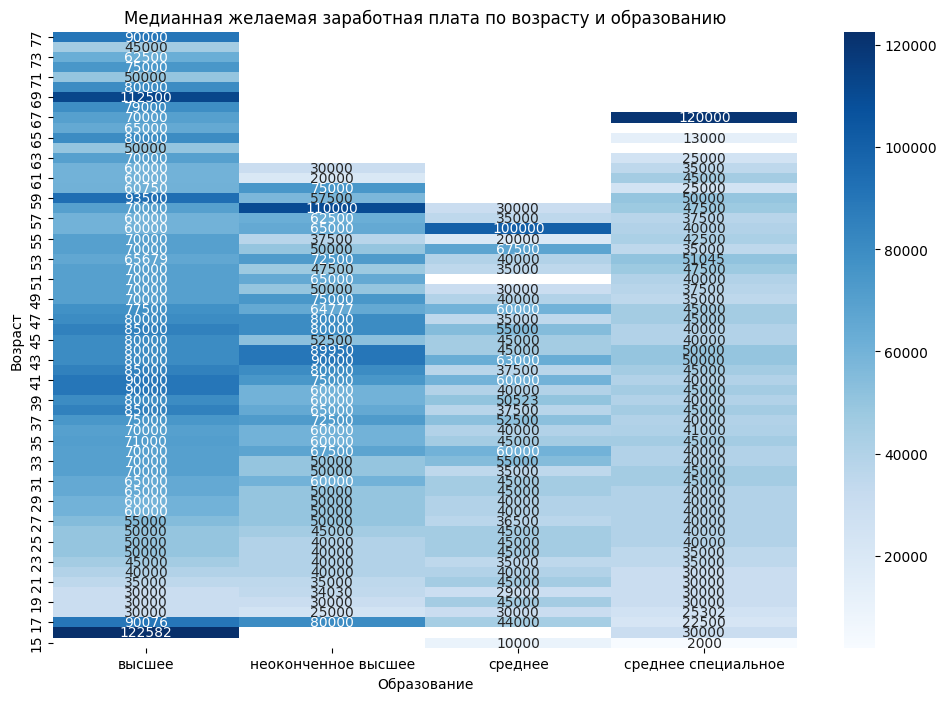

In [79]:
pivot_tb = df.pivot_table(
    values='ЗП (руб)',
    index='Возраст',
    columns='Образование',
    aggfunc='median'
)

pivot_tb = pivot_tb.sort_index(ascending=False)

plt.figure(figsize=(12, 8))

sns.heatmap(
    pivot_tb,
    annot=True,        
    fmt='.0f',         
    cmap='Blues'
)

plt.title('Медианная желаемая заработная плата по возрасту и образованию')
plt.xlabel('Образование')
plt.ylabel('Возраст')

plt.show()
    

В целом наблюдается связь между возрастом и зарплатными ожиданиями: в начале карьеры ожидаемая заработная плата ниже, чем у более возрастных соискателей. Наиболее выражена эта тенденция для высшего образования, несколько слабее — для неоконченного высшего и практически не выражена для среднего специального образования.

Для высшего и неоконченного высшего образования также выделяются повышенные зарплатные ожидания в диапазонах 40–44 и 58–59 лет. В возрасте старше 55 лет повышенные значения наблюдаются для всех уровней образования. При этом на фоне более низких значений в соседних возрастных группах они выглядят как отдельные всплески. С учётом того, что медианный возраст соискателей составляет около 31 года, эти значения могут быть обусловлены небольшим количеством резюме с высокими зарплатными ожиданиями, в том числе на руководящие позиции. Однако это стоит подтвердить количеством наблюдений в соответствующих группах.

В возрасте 16–17 лет наблюдаются необычно высокие значения зарплатных ожиданий для категорий высшего и неоконченного высшего образования. Само наличие таких сочетаний возраста и образования вызывает вопросы, поэтому их стоит дополнительно проверить.

In [80]:
df[(df['Возраст'] > 55)&(df['ЗП (руб)'] > 93000)].shape[0]

190

In [81]:
df[(df['Возраст'] > 55)&(df['ЗП (руб)'] > 93000)].sort_values('Образование')

,Ищет работу на должность:,Последнее/нынешнее место работы,Последняя/нынешняя должность,Обновление резюме,Авто,Пол,Возраст,ЗП_сумма,ЗП_валюта,ЗП (руб),...,стажировка,волонтерство,гибкий график,полный день,сменный график,вахтовый метод,удаленная работа,Опыт работы (лет),Образование,ЗП (тыс. руб)
436,Аккаунт-менеджер/ руководитель направления/ ру...,"ООО ""Информационные системы и стратегии",Продакт-менеджер,2019-05-07,Имеется собственный автомобиль,Мужчина,56,170000.0,руб.,170000.0,...,False,False,False,True,False,False,False,34.750000,высшее,170.0
27695,"Руководитель направления, технический директор","ООО ""Корпоративная автоматизация""",Координатор проектов автоматизации,2019-04-25,Имеется собственный автомобиль,Мужчина,56,120000.0,руб.,120000.0,...,False,False,False,True,False,False,False,18.500000,высшее,120.0
27846,Руководитель проекта,ООО Монолит,Начальник участка,2019-05-07,Не указано,Мужчина,59,100000.0,руб.,100000.0,...,False,False,False,True,False,False,False,32.416667,высшее,100.0
27857,Руководитель проекта,ООО «ВариоСтар»,Начальник отдела управления проектами,2019-05-07,Имеется собственный автомобиль,Мужчина,57,120000.0,руб.,120000.0,...,False,False,False,True,False,False,False,18.833333,высшее,120.0
28695,Радиоинженер,ФГБУН ИКИ РАН,Ведущий инженер,2019-04-27,Не указано,Мужчина,59,100000.0,руб.,100000.0,...,False,False,False,True,True,False,False,36.083333,высшее,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32405,Консультант ITSM,"ЗАО ""ДХЛ Интернешнл""",Координатор по развитию программных таможенных...,2019-04-25,Имеется собственный автомобиль,Мужчина,58,110000.0,руб.,110000.0,...,False,False,True,True,True,False,False,25.250000,неоконченное высшее,110.0
16642,программист 1С,"ООО ""Краски лета""",Программист,2019-04-09,Не указано,Мужчина,56,100000.0,руб.,100000.0,...,False,False,False,True,False,False,False,15.083333,неоконченное высшее,100.0
40072,"Администратор MS SQL, программист БД",Manzana Group,Разработчик,2018-06-18,Не указано,Мужчина,56,100000.0,руб.,100000.0,...,False,False,False,True,False,False,False,27.583333,среднее,100.0
1956,Ведущий инженер-разработчик АСУТП,ООО «Воронеж-Аква»,Начальник отдела АСУТП и энергообеспечения Деп...,2019-04-21,Не указано,Мужчина,58,130000.0,руб.,130000.0,...,False,False,False,True,False,False,False,34.250000,среднее специальное,130.0


Действительно видим небольше количество соискателей старше 55 лет с высокими зарплатными ожиданиями. 
Эти данные не выглядят аномальными: значительная часть таких соискателей претендует на руководящие или ведущие позиции.

In [82]:
df[
    (df['Возраст'] <= 18) &
    (df['ЗП (руб)'] >= 90_000)
]

,Ищет работу на должность:,Последнее/нынешнее место работы,Последняя/нынешняя должность,Обновление резюме,Авто,Пол,Возраст,ЗП_сумма,ЗП_валюта,ЗП (руб),...,стажировка,волонтерство,гибкий график,полный день,сменный график,вахтовый метод,удаленная работа,Опыт работы (лет),Образование,ЗП (тыс. руб)
30901,Программист Java,Google Inc.,Менеджер проекта,2019-04-26,Не указано,Мужчина,17,1000000.0,KZT,170151.00,...,False,False,False,True,False,False,False,5.000000,высшее,170.15100
33544,Android Developer - Middle,Klaizar Studio,Android developer,2019-04-13,Не указано,Мужчина,16,1900.0,USD,122582.49,...,False,False,False,False,False,False,True,2.833333,высшее,122.58249


Данные о возрасте до 18 лет при наличии высшего образования с высокими зарплатными ожиданиями выглядят некорректно и, скорее всего, связаны с ошибками в данных. Поэтому исключим эти данные из дальнейшего анализа.

In [83]:
df = df[
    ~(
        (df['Возраст'] <= 18) &
        (df['ЗП (руб)'] >= 90_000)
    )
]

4.6. Посмотрим на зависимость опыт работы от возраста

Text(0, 0.5, 'Уровень желаемой заработной платы')

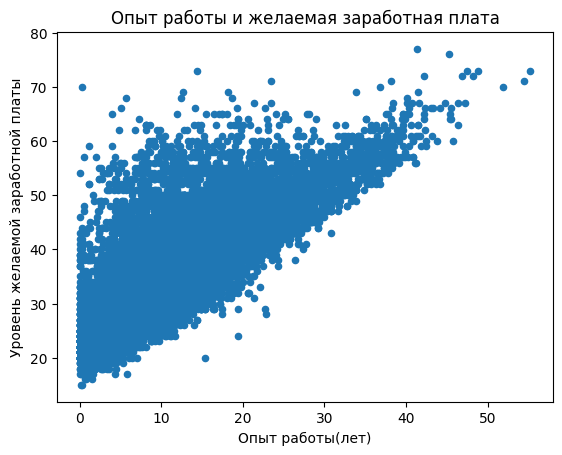

In [84]:
df.plot.scatter(
    x='Опыт работы (лет)',
    y='Возраст'
)

plt.title('Опыт работы и желаемая заработная плата')
plt.xlabel('Опыт работы(лет)')
plt.ylabel('Уровень желаемой заработной платы')

Наблюдается сильная положительная корреляция между опытом и возрастом.
На графике видна четкая прямая линия, ограничивающая точки снизу. Судя по графику, большинство людей начинают карьеру в возрасте от 15 до 20 лет.
Так же график показывает новые вероятные ошибки в данных.Например, есть точка с опытом работы около 15 лет при возрасте в 20 лет. Для исключения выбросов удалим данные, где разница между возрастом и опытом работы превышает 15 лет.

In [85]:
df = df[df['Возраст'] - df['Опыт работы (лет)'] >= 15]

Text(0, 0.5, 'Уровень желаемой заработной платы')

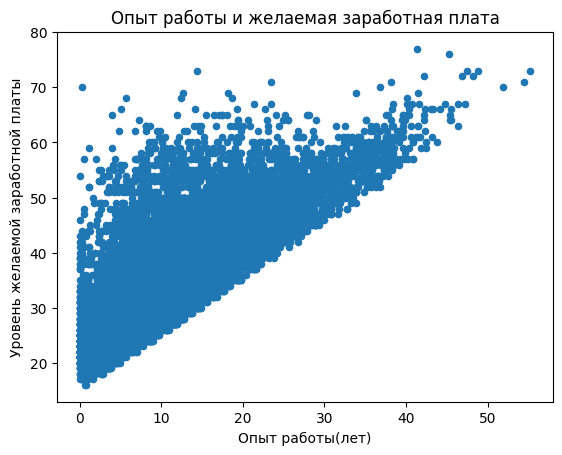

In [86]:
df.plot.scatter(
    x='Опыт работы (лет)',
    y='Возраст'
)

plt.title('Опыт работы и желаемая заработная плата')
plt.xlabel('Опыт работы(лет)')
plt.ylabel('Уровень желаемой заработной платы')

4.7. Рассмотрим как влияет пол кандидата на его зарплатные ожидания

Text(0.5, 1.0, 'Зависимость пола и зарплатных ожиданий')

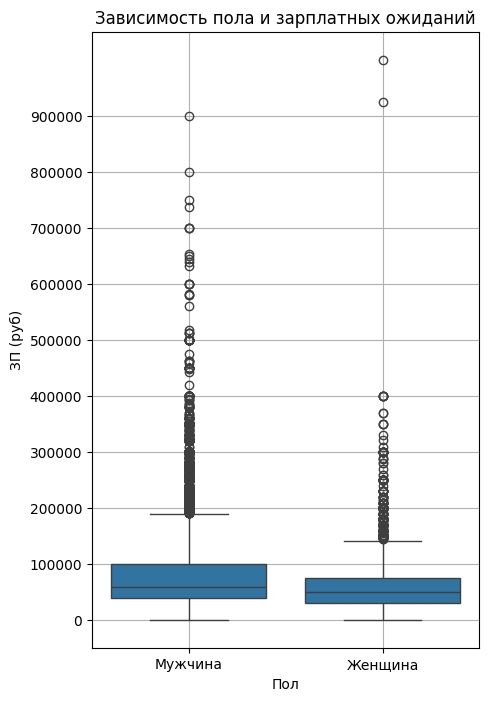

In [87]:
ig, ax = plt.subplots(figsize=(5, 8))

sns.boxplot(
    data=df,
    x='Пол',
    y='ЗП (руб)',
    ax=ax
)

ax.set_yticks(range(0, 1_000_000, 100_000))
ax.grid()

ax.set_title('Зависимость пола и зарплатных ожиданий')

Мужчины в среднем претендуют на более высокий уровень заработной платы во всех квартилях (Q1, медиана, Q3), а также значительно чаще запрашивают зарплаты выше 200 000 рублей. 
Оба распределения имеют сильную правую асимметрию: зарплатные ожидания большинства невысокие или средние, и лишь у некоторых они очень большие. При этом у мужчин высоких зарплатных ожиданий больше, хотя максимальные значения наблюдаются у женщин

4.8. Рассмотрим зависимость зарплатных ожиданий от типа занятости.

Text(0.5, 1.0, 'Завсисимость типа занятости и зарплатных ожиданий')

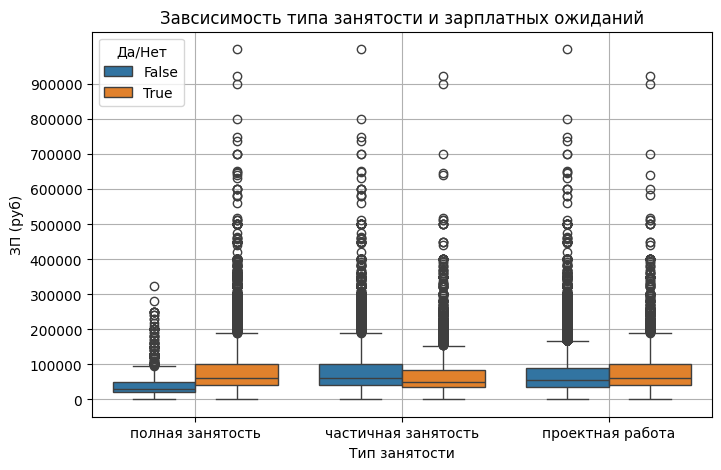

In [88]:
ig, ax = plt.subplots(figsize=(8, 5))

df_schedule = df.melt(
    id_vars='ЗП (руб)',
    value_vars=[
        'полная занятость',
        'частичная занятость',
        'проектная работа'
    ],
    var_name='Тип занятости',
    value_name='Да/Нет'
)

sns.boxplot(
    data=df_schedule,
    x='Тип занятости',
    y='ЗП (руб)',
    hue='Да/Нет'
)

ax.set_yticks(range(0, 1000000, 100000))
ax.grid()

ax.set_title('Завсисимость типа занятости и зарплатных ожиданий')

Наибольшая разница в уровнях заработной платы наблюдается при полной занятости, где соискатели, готовые к данному типу занятости, демонстрируют существенно более высокую медиану, широкий диапазон ожиданий и большее количество высоких значений.
При частичной занятости картина меняется: медиана у кандидатов, не готовых к этому формату, медиана и весь основной диапазон зарплатных ожиданий оказывается немного выше.
В проектной работе распределения при наличии и отсутствии готовности наиболее близки друг другу.

При сравнении самих типов занятости между собой наибольший уровень зарплатных ожиданий наблюдается при полной занятости и проектной работе, тогда как при частичной занятости запросы в среднем ниже.